# 01 — Data Download & Inspection

Loads the pre-downloaded ETF universe and runs visual QC checks.
Run `python main.py` from the project root first if you haven't already.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import yaml

from src.data import load_prices, load_spreads, load_risk_free_rate, compute_returns, load_config

plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (14, 5)})

PROC = '../data/processed'
RAW  = '../data/raw'
CFG  = '../config/universe.yaml'

## 1. Load data

In [2]:
prices = load_prices(PROC)
spreads = load_spreads(PROC)
rf = load_risk_free_rate(PROC)
returns = compute_returns(prices)
cfg = load_config(CFG)

print(f'Price matrix : {prices.shape[0]:,} days × {prices.shape[1]} tickers')
print(f'Date range   : {prices.index[0].date()} → {prices.index[-1].date()}')
print(f'Tickers      : {list(prices.columns)}')

Price matrix : 5,403 days × 15 tickers
Date range   : 2005-01-03 → 2026-06-25
Tickers      : ['BIL', 'DBC', 'EEM', 'GLD', 'IEF', 'IWM', 'QQQ', 'SHY', 'SLV', 'SPY', 'TLT', 'UNG', 'USO', 'VGK', 'VNQ']


## 2. Adjusted close prices

In [3]:
prices.head()

Ticker,BIL,DBC,EEM,GLD,IEF,IWM,QQQ,SHY,SLV,SPY,TLT,UNG,USO,VGK,VNQ
Date,,,,,,,,,,,,,,,
2005-01-03,NaN,NaN,14.487370,43.020000,47.930340,48.074982,33.615993,54.095024,NaN,81.174606,44.222569,NaN,NaN,NaN,22.350887
2005-01-04,NaN,NaN,14.041329,42.740002,47.631901,47.044426,33.003262,53.975452,NaN,80.182701,43.759098,NaN,NaN,NaN,22.014957
2005-01-05,NaN,NaN,13.869441,42.669998,47.710747,46.104118,32.799007,53.988712,NaN,79.629379,43.993309,NaN,NaN,NaN,21.283127
2005-01-06,NaN,NaN,13.860008,42.150002,47.755764,46.348591,32.637306,54.015312,NaN,80.034241,44.023212,NaN,NaN,NaN,21.447086
2005-01-07,NaN,NaN,13.886845,41.840000,47.716354,45.833321,32.807526,54.021996,NaN,79.919548,44.122906,NaN,NaN,NaN,21.399105


In [4]:
prices.tail()

Ticker,BIL,DBC,EEM,GLD,IEF,IWM,QQQ,SHY,SLV,SPY,TLT,UNG,USO,VGK,VNQ
Date,,,,,,,,,,,,,,,
2026-06-18,91.570000,27.629999,70.790001,387.119995,94.360001,295.589996,739.807007,81.989998,59.509998,746.739990,86.750000,11.7400,114.870003,88.269997,94.725090
2026-06-22,91.570000,27.410000,71.209999,384.589996,94.000000,298.179993,737.950012,81.910004,58.910000,744.390015,86.089996,11.7700,112.690002,88.250000,95.746094
2026-06-23,91.580002,27.120001,67.169998,377.320007,94.120003,295.320007,713.650024,81.970001,55.730000,733.580017,86.199997,11.5000,111.260002,87.160004,97.004997
2026-06-24,91.589996,26.450001,67.250000,365.920013,94.730003,296.690002,710.619995,82.070000,51.779999,733.239990,87.379997,11.7300,106.290001,86.949997,97.010002
2026-06-25,91.600098,26.844999,68.370003,370.619995,94.904999,299.510010,718.599976,82.129997,53.090000,735.960022,87.455002,11.8615,108.680000,88.190002,96.544998


## 3. Normalised price chart (base = 100 at first available date)

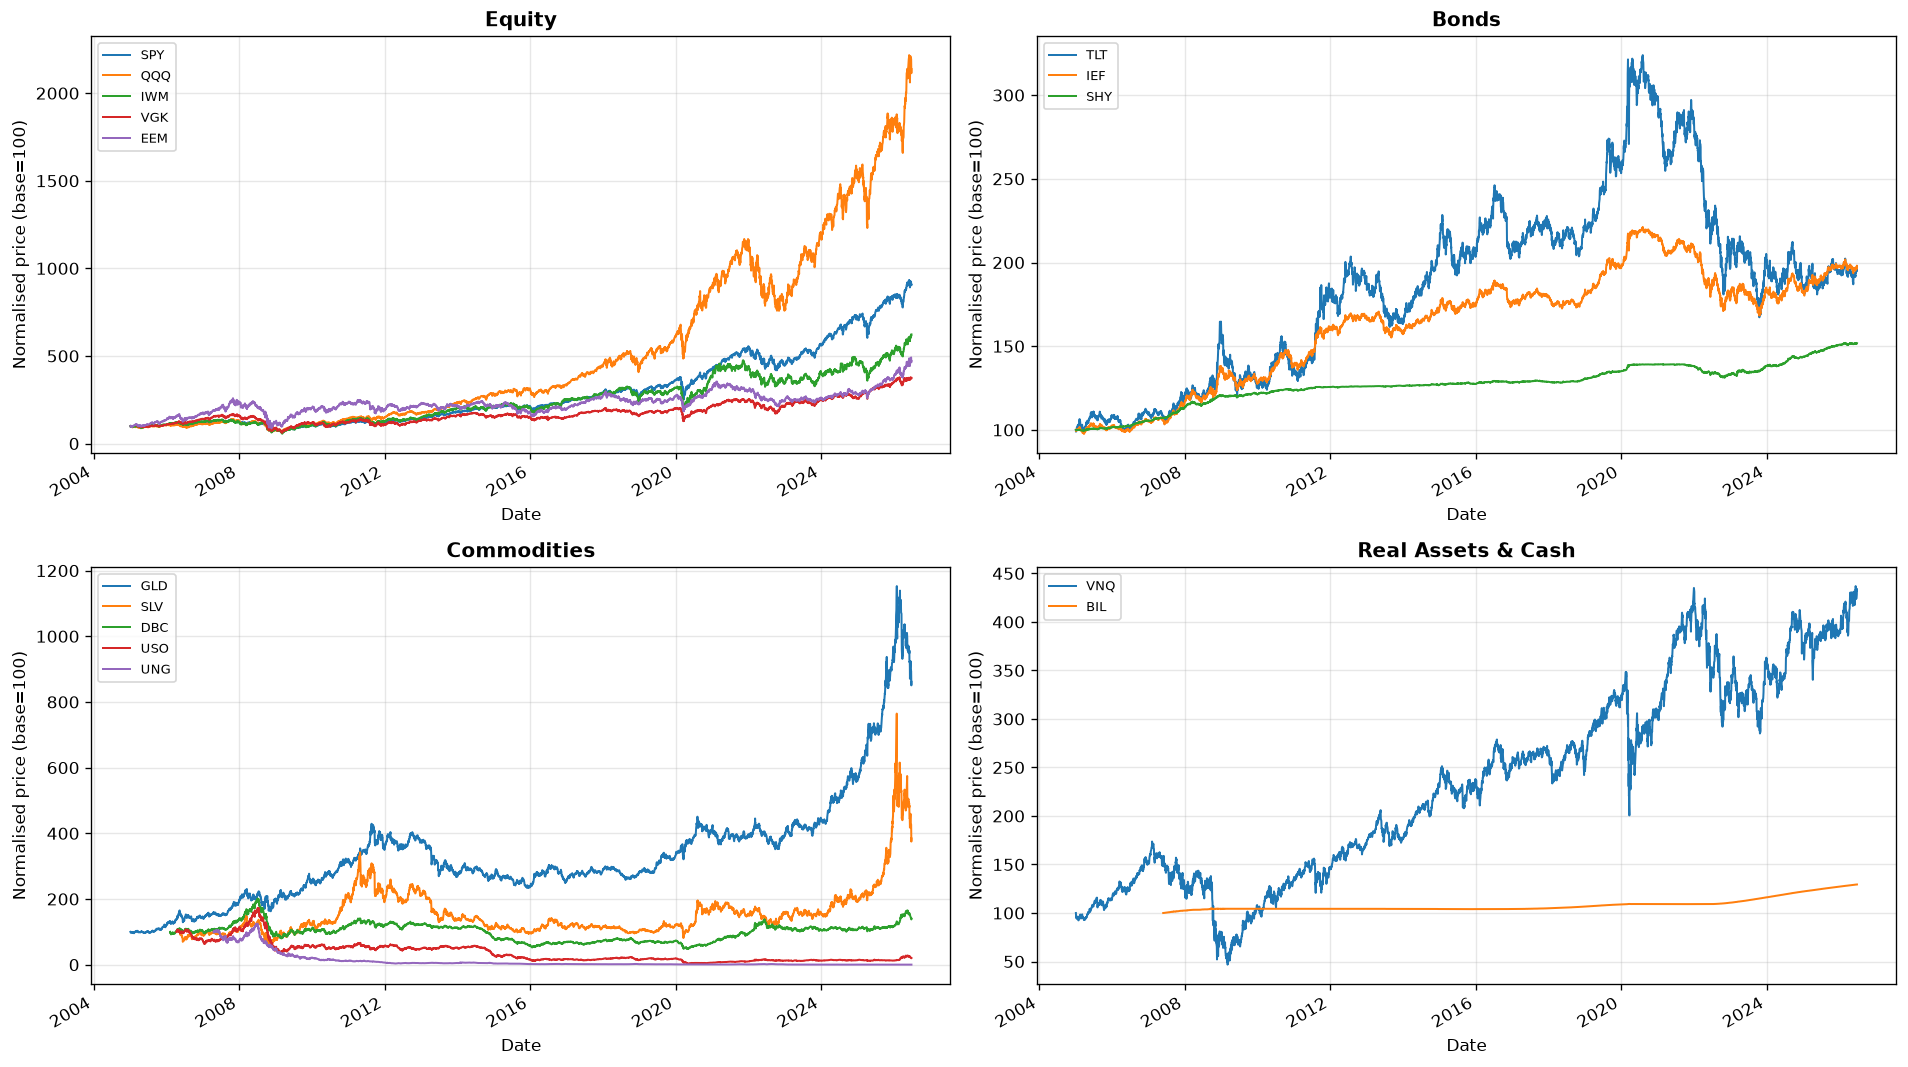

In [5]:
# Group by asset class for cleaner charts
groups = {
    'Equity':      cfg['universe']['equity'],
    'Bonds':       cfg['universe']['bonds'],
    'Commodities': cfg['universe']['commodities'],
    'Real Assets & Cash': cfg['universe']['real_assets'] + cfg['universe']['cash_proxy'],
}

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

for ax, (title, tickers) in zip(axes, groups.items()):
    subset = prices[tickers].dropna(how='all')
    normed = subset.div(subset.bfill().iloc[0]) * 100
    normed.plot(ax=ax, linewidth=1.2)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Normalised price (base=100)')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Missing data heatmap

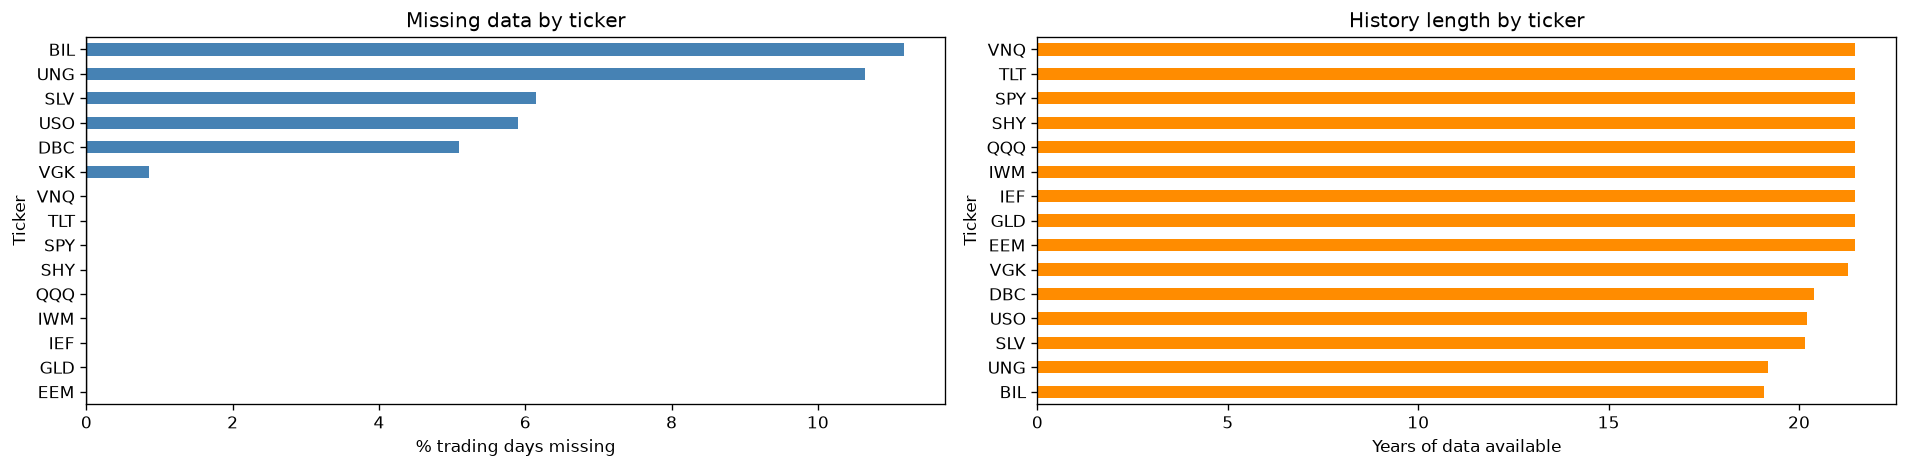


First valid date per ticker:
Ticker
EEM   2005-01-03
GLD   2005-01-03
IEF   2005-01-03
IWM   2005-01-03
QQQ   2005-01-03
SHY   2005-01-03
SPY   2005-01-03
TLT   2005-01-03
VNQ   2005-01-03
VGK   2005-03-10
DBC   2006-02-06
USO   2006-04-10
SLV   2006-04-28
UNG   2007-04-18
BIL   2007-05-30


In [6]:
missing = prices.isna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

# % missing per ticker
pct = (missing.mean() * 100).sort_values(ascending=True)
pct.plot.barh(ax=ax1, color='steelblue')
ax1.set_xlabel('% trading days missing')
ax1.set_title('Missing data by ticker')
ax1.axvline(0, color='black', linewidth=0.8)

# First available date per ticker
first_date = prices.apply(lambda col: col.first_valid_index())
years_available = ((prices.index[-1] - first_date).dt.days / 365.25).sort_values()
years_available.plot.barh(ax=ax2, color='darkorange')
ax2.set_xlabel('Years of data available')
ax2.set_title('History length by ticker')

plt.tight_layout()
plt.show()

print('\nFirst valid date per ticker:')
print(first_date.sort_values().to_string())

## 5. Return statistics

In [7]:
ann = 252
stats = pd.DataFrame({
    'Ann. Return %':   (returns.mean() * ann * 100).round(2),
    'Ann. Vol %':      (returns.std() * np.sqrt(ann) * 100).round(2),
    'Sharpe (rf=0)':  (returns.mean() / returns.std() * np.sqrt(ann)).round(3),
    'Skew':            returns.skew().round(3),
    'Kurt':            returns.kurtosis().round(3),
    'Max DD %':        ((prices / prices.cummax() - 1).min() * 100).round(2),
}).sort_values('Ann. Return %', ascending=False)

stats

,Ann. Return %,Ann. Vol %,Sharpe (rf=0),Skew,Kurt,Max DD %
Ticker,,,,,,
QQQ,14.29,21.64,0.660,-0.254,7.555,-53.40
SPY,10.28,18.97,0.542,-0.304,14.698,-55.19
GLD,10.05,18.24,0.551,-0.459,6.759,-45.56
IWM,8.53,24.15,0.353,-0.510,6.858,-58.64
EEM,7.24,27.61,0.262,0.023,15.631,-66.43
VNQ,6.83,28.59,0.239,-0.536,18.845,-73.07
SLV,6.69,33.77,0.198,-1.559,18.894,-76.28
VGK,6.22,22.92,0.271,-0.610,11.002,-63.61
IEF,3.19,6.75,0.472,0.108,2.698,-23.92


## 6. Correlation matrix

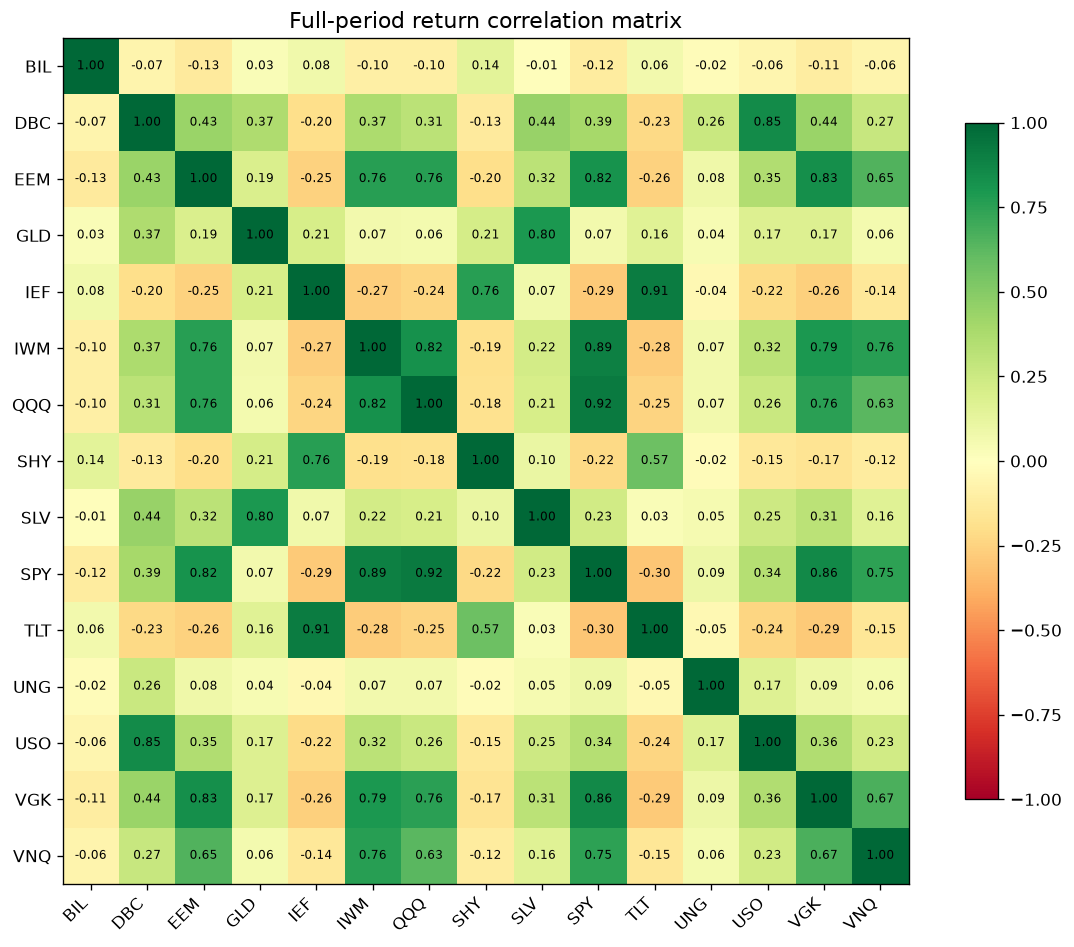

In [8]:
import matplotlib.colors as mcolors

corr = returns.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)

tickers = corr.columns.tolist()
ax.set_xticks(range(len(tickers)))
ax.set_yticks(range(len(tickers)))
ax.set_xticklabels(tickers, rotation=45, ha='right')
ax.set_yticklabels(tickers)

for i in range(len(tickers)):
    for j in range(len(tickers)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=7)

ax.set_title('Full-period return correlation matrix', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Bid-ask spread estimates (Corwin-Schultz)

In [9]:
spread_summary = (spreads * 100).describe().T[['mean', '50%', '75%', 'max']]
spread_summary.columns = ['Mean %', 'Median %', '75th pct %', 'Max %']
spread_summary.sort_values('Mean %').round(4)

,Mean %,Median %,75th pct %,Max %
BIL,0.0169,0.0124,0.0218,0.9309
SHY,0.0195,0.0000,0.0285,0.6142
IEF,0.0669,0.0000,0.1058,1.3360
TLT,0.1564,0.0000,0.2624,6.3591
GLD,0.1715,0.0000,0.2723,2.6966
VGK,0.1875,0.0000,0.2555,5.1771
EEM,0.2334,0.0000,0.3224,7.2824
DBC,0.2469,0.0000,0.4074,4.2540
SPY,0.2586,0.0000,0.3705,7.3368
SLV,0.3158,0.0000,0.5113,4.8747


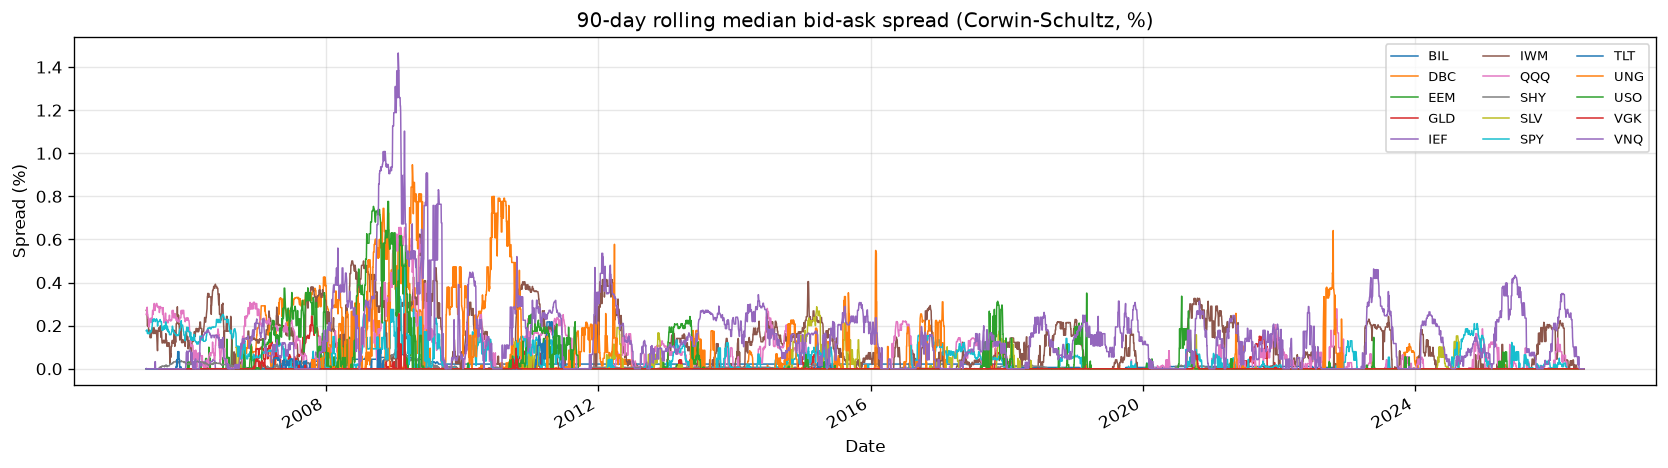

In [10]:
# 90-day rolling median spread
roll_spread = spreads.rolling(90).median() * 100
roll_spread.plot(linewidth=0.9, figsize=(14, 4))
plt.title('90-day rolling median bid-ask spread (Corwin-Schultz, %)')
plt.ylabel('Spread (%)')
plt.legend(loc='upper right', fontsize=8, ncol=3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Risk-free rate

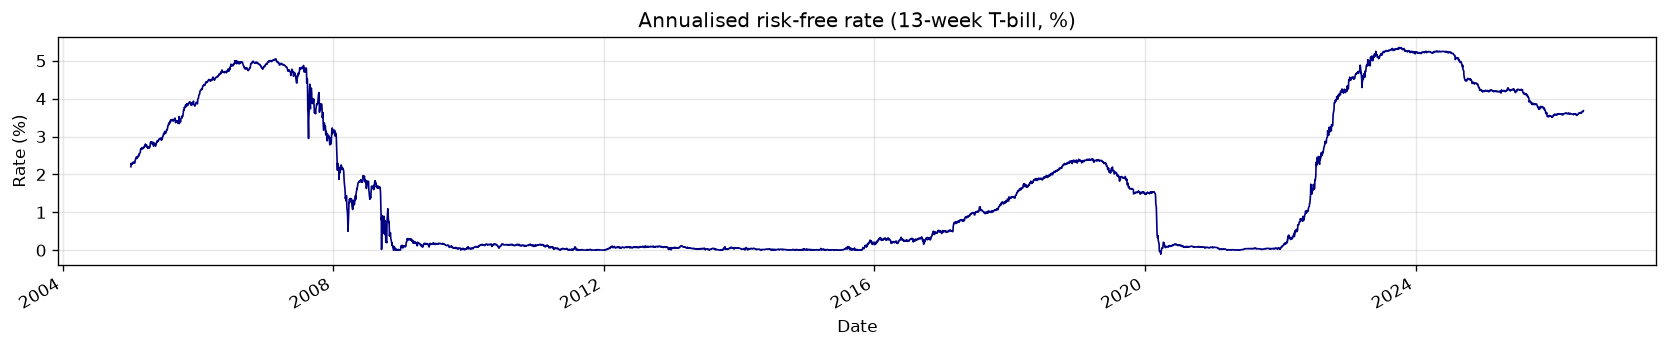

Current daily rf rate : 0.01461%  (3.68% annualised)


In [11]:
(rf * 252 * 100).plot(linewidth=1, color='navy', figsize=(14, 3))
plt.title('Annualised risk-free rate (13-week T-bill, %)')
plt.ylabel('Rate (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Current daily rf rate : {rf.iloc[-1]*100:.5f}%  ({rf.iloc[-1]*252*100:.2f}% annualised)')

## 9. Expense ratios

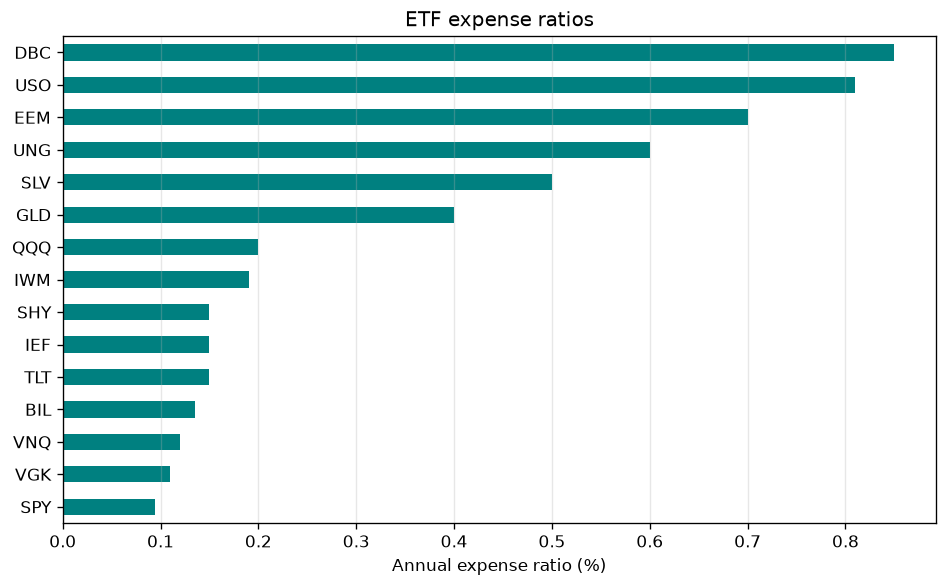

In [12]:
er = pd.Series(cfg['expense_ratios']) * 100
er = er.sort_values(ascending=True)

er.plot.barh(color='teal', figsize=(8, 5))
plt.xlabel('Annual expense ratio (%)')
plt.title('ETF expense ratios')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()